In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/food-101")

print("Path to dataset files:", path)

/home/yuewang/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████████████████████████████████████████████████████████████████████████| 9.38G/9.38G [02:53<00:00, 58.1MB/s]

Extracting files...


Path to dataset files: /home/yuewang/.cache/kagglehub/datasets/dansbecker/food-101/versions/1


In [2]:
import os

print(os.listdir(path))

['food-101.zip', 'food-101']


In [3]:
from torchvision import datasets, transforms

data_dir = path + "/food-101/food-101/images"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)

print(len(dataset))
print(dataset.classes[:5])

101000
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


apple_pie


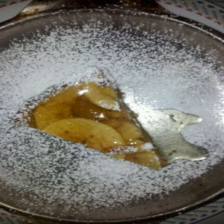

apple_pie


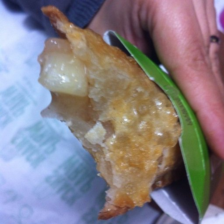

apple_pie


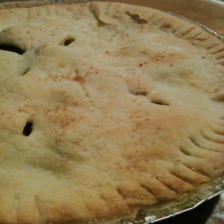

apple_pie


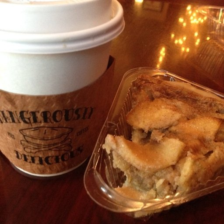

apple_pie


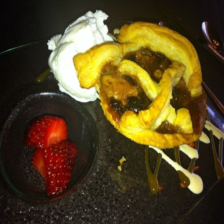

In [4]:
from IPython.display import display
from torchvision.transforms.functional import to_pil_image

for i in range(5):
    img, label = dataset[i]
    img = to_pil_image(img)
    
    print(dataset.classes[label])
    display(img)

**Below is the initialization block for all models, in case each model needs a kernel restart. There are many problems in Windows/Jupyter in this project like dataloaders, OOM, and matplotlib/training DLLs so I had to restart kernel, run the below block, and run the model I wanted.**

In [1]:
# Jupyter lab does not clear memory between models so if it OOMs or kernel dies rerun this initialization block every time
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/food-101")

from torchvision import datasets, transforms

data_dir = path + "/food-101/food-101/images"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

import gc

def clear_all():
    global_vars = ["model", "optimizer"]

    for var in global_vars:
        if var in globals():
            del globals()[var]

    gc.collect()
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

import os
from PIL import Image
from torch.utils.data import Dataset

class Food101Dataset(Dataset):
    def __init__(self, root, split_file, transform=None):
        self.root = root
        self.transform = transform
        
        with open(split_file) as f:
            self.samples = f.read().splitlines()
        
        self.classes = sorted(set(x.split('/')[0] for x in self.samples))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        label_name = item.split('/')[0]
        
        img_path = os.path.join(self.root, "images", item + ".jpg")
        img = Image.open(img_path).convert("RGB")
        
        if self.transform:
            img = self.transform(img)
        
        label = self.class_to_idx[label_name]
        return img, label
    
    
# Train/Test split

base_path = path + "/food-101/food-101"

train_dataset = Food101Dataset(
    root=base_path,
    split_file=base_path + "/meta/train.txt",
    transform=transform
)

test_dataset = Food101Dataset(
    root=base_path,
    split_file=base_path + "/meta/test.txt",
    transform=transform
)

from torch.utils.data import random_split
import random
import numpy as np

seed = 77 # Set a seed so sets are the same each time, as every model causes kernel crash if I try to continue

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory = True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True)

# Training function

import torch
import time

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=3,
    save_path="best_linear_model_vit.pth"
):
    best_val_loss = float('inf')
    counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    total_start = time.time()  # Total training time

    for epoch in range(epochs):
        epoch_start = time.time()  # Start epoch timer

        # Train
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validate
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        # Compute epoch time
        epoch_time = time.time() - epoch_start
        history["epoch_time"].append(epoch_time)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.2f}s")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0

            torch.save(model.state_dict(), save_path)
            print("Best model saved")

        else:
            counter += 1
            print(f"No improvement ({counter}/{patience})")

            if counter >= patience:
                print("Early stopping triggered")
                break

    # Total time
    total_time = time.time() - total_start
    print(f"\nTotal training time: {total_time:.2f}s")

    history["total_time"] = total_time

    return history

/home/yuewang/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**First we start with linear probing, which is freezing all parameters and then unfreezing just the classifier**

In [2]:
clear_all()

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)
model.heads.head = nn.Linear(model.heads.head.in_features, 101)

for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.heads.parameters(), lr=1e-3)

cuda


In [3]:
import json
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    patience=2
)

#Looking at task manager takes around 1.5 gb of vram

# Save history locally in case of kernel crash
with open("history_linear.json", "w") as f:
    json.dump(history, f)

KeyboardInterrupt: 

**After training plot some graphs to make sure it plateaued**

**Then we start PEFT by doing BatchNorm equivalent, LayerNorm Tuning For ViT. This is simplest one so done first.**

In [9]:
import torch.nn as nn

clear_all()

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)
model.heads.head = nn.Linear(model.heads.head.in_features, 101)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze classifier
for p in model.heads.parameters():
    p.requires_grad = True

# Unfreeze LayerNorm (ViT equivalent of BN tuning)
for m in model.modules():
    if isinstance(m, nn.LayerNorm):
        if m.weight is not None:
            m.weight.requires_grad = True
        if m.bias is not None:
            m.bias.requires_grad = True
        
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

cuda


In [10]:
import json
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    patience=2,
    save_path="batch_norm_model.pth"
)

#Looking at task manager takes around 6 gb of vram

#Save history locally in case of kernel crash
with open("history_bn.json", "w") as f:
    json.dump(history, f)

KeyboardInterrupt: 

Plotting again to make sure plateaued

**Next should be Task Specific Adapters**

In [11]:
import torch.nn as nn

clear_all()

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)
model.heads.head = nn.Linear(model.heads.head.in_features, 101)

class Adapter(nn.Module):
    def __init__(self, dim, reduction=16):
        super().__init__()
        self.down = nn.Linear(dim, dim // reduction)
        self.up = nn.Linear(dim // reduction, dim)

    def forward(self, x):
        return x + self.up(torch.relu(self.down(x)))
    
class ViTWithAdapter(nn.Module):
    def __init__(self, model, num_classes=101):
        super().__init__()
        self.model = model
        self.adapter = Adapter(model.heads.head.in_features)
        self.head = nn.Linear(model.heads.head.in_features, num_classes)

    def forward(self, x):
        x = self.model._process_input(x)
        n = x.shape[0]
        cls_token = self.model.class_token.expand(n, -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        x = self.model.encoder(x)

        x = x[:, 0]

        x = self.adapter(x)

        return self.head(x)
    

weights = ViT_B_16_Weights.IMAGENET1K_V1
base_model = vit_b_16(weights=weights)

model = ViTWithAdapter(base_model, num_classes=101)
    
for p in model.parameters():
    p.requires_grad = False
    
for p in model.adapter.parameters():
    p.requires_grad = True

for p in model.head.parameters():
    p.requires_grad = True
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

cuda


In [12]:
import json
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    patience=2,
    save_path="adapter_model.pth"
)

#Looking at task manager takes around 1.8 gb of vram

#Save history locally in case of kernel crash
with open("history_adapter.json", "w") as f:
    json.dump(history, f)

KeyboardInterrupt: 

**Finally we can do LoRA, it's different for ViT, like BatchNorm, and requires a bit of modification to make it a bit easier**

In [13]:
import torch
import torch.nn as nn

clear_all()

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)
model.heads.head = nn.Linear(model.heads.head.in_features, 101)

class LoRALinear(nn.Module):
    def __init__(self, linear, r=4, alpha=1.0):
        super().__init__()
        self.linear = linear  # original frozen layer
        self.r = r
        self.alpha = alpha

        in_dim = linear.in_features
        out_dim = linear.out_features

        # LoRA matrices
        self.A = nn.Linear(in_dim, r, bias=False)
        self.B = nn.Linear(r, out_dim, bias=False)

        # scale
        self.scaling = alpha / r

        # freeze original
        for p in self.linear.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.linear(x) + self.B(self.A(x)) * self.scaling
    
def apply_lora(model, r=4):
    for name, module in list(model.named_modules()):

        if "mlp" in name and "fc1" in name and isinstance(module, nn.Linear):

            parent = model
            *path, last = name.split(".")

            for p in path:
                parent = getattr(parent, p)

            setattr(parent, last, LoRALinear(module, r=r))

In [14]:
in_dim = model.heads.head.in_features
model.heads.head = nn.Linear(in_dim, 101)

apply_lora(model, r=8)

for p in model.parameters():
    p.requires_grad = False

for m in model.modules():
    if isinstance(m, LoRALinear):
        for p in m.parameters():
            p.requires_grad = True

for p in model.heads.parameters():
    p.requires_grad = True
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4 # LoRA needs 
)

cuda


In [15]:
import json
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    patience=2,
    save_path="lora_model.pth"
)

#Looking at task manager only takes around 1.9 gb of vram

#Save history locally in case of kernel crash
with open("history_lora.json", "w") as f:
    json.dump(history, f)

KeyboardInterrupt: 

**Halted manually as it was taking too long and was good enough**

**The final training we do is full fine tuning, essentially leaving all weights unfrozen**

In [2]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch.nn as nn

clear_all()

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)

# replace classifier
in_dim = model.heads.head.in_features
model.heads.head = nn.Linear(in_dim, 101)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

cuda


In [17]:
import json
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    patience=2,
    save_path="full_model.pth"
)

#Looking at task manager takes around 10.1 gb of vram

#Save history locally in case of kernel crash
with open("history_full.json", "w") as f:
    json.dump(history, f)

KeyboardInterrupt: 